**1. IMPORT LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

**2. GENERATE MULTI-CELL NETWORK TRAFFIC**

In [ ]:
np.random.seed(42)

time_steps = 500
time = np.arange(time_steps)
base_traffic = 50 + 20*np.sin(0.1*time) + np.random.normal(0, 5, time_steps)

cell_1 = base_traffic + np.random.normal(0, 2, time_steps)
cell_2 = base_traffic + np.random.normal(0, 3, time_steps)
cell_3 = base_traffic + np.random.normal(0, 4, time_steps)

traffic = (cell_1 + cell_2 + cell_3) / 3

df = pd.DataFrame({'time': time, 'traffic': traffic})

**3. CREATE TIME-SERIES FEATURES**

In [ ]:
def create_features(data, window=5):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 5
X, y = create_features(df['traffic'].values, window)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

**4. TRAIN ML MODEL**

In [ ]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 48.78210892743857


**5. DYNAMIC THRESHOLD (ADAPTIVE)**

In [ ]:
threshold = np.mean(y_train) + np.std(y_train)
print("Dynamic Congestion Threshold:", threshold)

Dynamic Congestion Threshold: 65.96069860883856


**6. ADAPTIVE OPTIMIZATION + LOAD BALANCING**

In [ ]:
optimized_traffic = []

for val in y_pred:
    if val > threshold:
        reduction_factor = min(0.5, (val - threshold)/val)
        val = val * (1 - reduction_factor)
        val = val * 0.85

    optimized_traffic.append(val)

optimized_traffic = np.array(optimized_traffic)

**7. LATENCY SIMULATION**

In [ ]:
latency_before = y_pred * 2
latency_after = optimized_traffic * 1.5

print("Avg Latency BEFORE:", np.mean(latency_before))
print("Avg Latency AFTER:", np.mean(latency_after))

Avg Latency BEFORE: 96.04535358307709
Avg Latency AFTER: 69.90153234227546


**8. QoS METRIC**

In [ ]:
qos_before = np.sum(y_pred < threshold) / len(y_pred)
qos_after = np.sum(optimized_traffic < threshold) / len(optimized_traffic)

print(f"QoS BEFORE: {qos_before:.2f}")
print(f"QoS AFTER: {qos_after:.2f}")

QoS BEFORE: 0.88
QoS AFTER: 1.00


**9. ANOMALY DETECTION**

In [ ]:
anomalies = []

for i in range(1, len(y_pred)):
    if abs(y_pred[i] - y_pred[i-1]) > 15:
        anomalies.append(i)

print("Detected Anomalies:", len(anomalies))

Detected Anomalies: 0


**10. ENERGY EFFICIENCY**

In [ ]:
energy_before = np.sum(y_pred**2)
energy_after = np.sum(optimized_traffic**2)

print("Energy BEFORE:", energy_before)
print("Energy AFTER:", energy_after)

Energy BEFORE: 244668.2872460381
Energy AFTER: 227220.42603813676


**11. PERFORMANCE METRICS**

In [ ]:
before = np.sum(y_pred > threshold)
after = np.sum(optimized_traffic > threshold)

print(f"Congestion BEFORE: {before}")
print(f"Congestion AFTER: {after}")

improvement = ((before - after) / before) * 100 if before != 0 else 0
print(f"Congestion Reduction: {improvement:.2f}%")

efficiency = np.mean(optimized_traffic) / np.mean(y_pred)
print(f"System Efficiency: {efficiency:.2f}")

Congestion BEFORE: 12
Congestion AFTER: 0
Congestion Reduction: 100.00%
System Efficiency: 0.97


**12. VISUALIZATION**

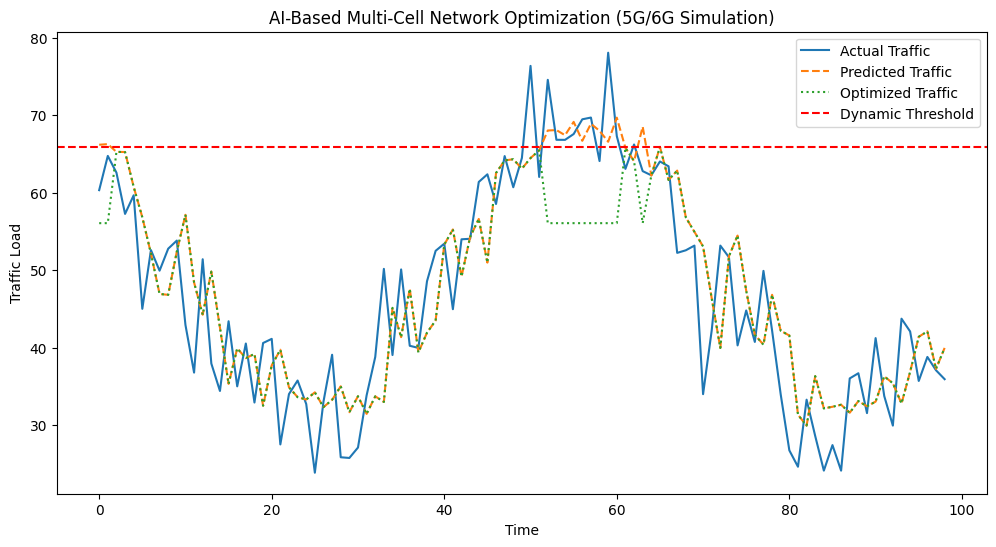

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual Traffic')
plt.plot(y_pred, label='Predicted Traffic', linestyle='dashed')
plt.plot(optimized_traffic, label='Optimized Traffic', linestyle='dotted')
plt.axhline(y=threshold, color='r', linestyle='--', label='Dynamic Threshold')

plt.legend()
plt.title("AI-Based Multi-Cell Network Optimization (5G/6G Simulation)")
plt.xlabel("Time")
plt.ylabel("Traffic Load")
plt.show()

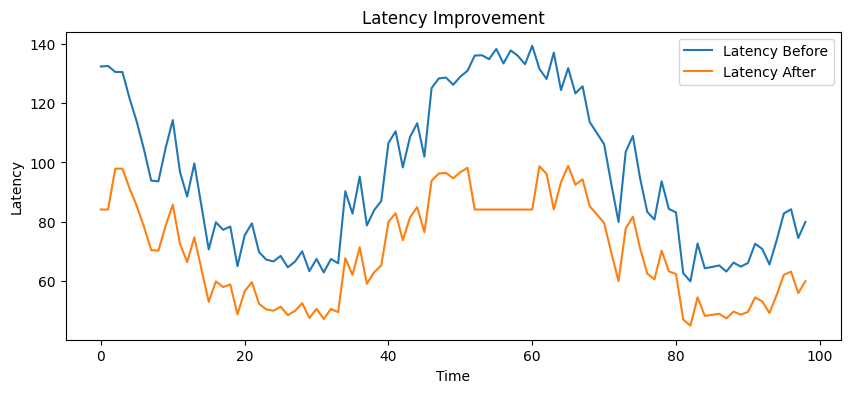

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(latency_before, label='Latency Before')
plt.plot(latency_after, label='Latency After')
plt.legend()
plt.title("Latency Improvement")
plt.xlabel("Time")
plt.ylabel("Latency")
plt.show()